In [1]:
# !pip install ta
# !pip install yfinance
# !pip install statsmodels
# !pip install xgboost
# !pip install tensorflow

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ta.momentum import RSIIndicator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (roc_curve, auc, ConfusionMatrixDisplay, classification_report, roc_auc_score, 
precision_score, f1_score, r2_score, mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix)

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor, XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# 1. Data Collection

In [3]:
# initializing stock variable
ticker = "GOOG"

# getting and displaying the data of 11 years of GOOG's stock history
data = yf.download(ticker, start="2014-01-01", end="2026-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2014-01-02,27.498323,27.612703,27.378263,27.556132,73129082
2014-01-03,27.297728,27.592444,27.295998,27.544767,66917888
2014-01-06,27.602079,27.640122,27.333301,27.495606,71037271
2014-01-07,28.134201,28.154706,27.696945,27.791807,102486711
2014-01-08,28.192749,28.343196,27.996600,28.310587,90036218


In [4]:
data.columns

MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

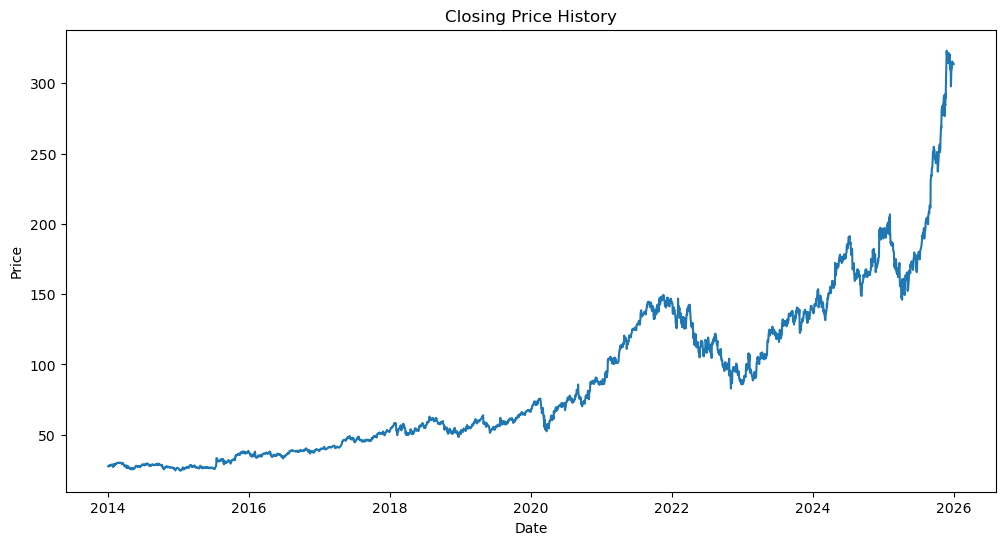

In [5]:
# display the closing price history
plt.figure(figsize=(12,6))

plt.plot(data["Close"])

plt.title("Closing Price History")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

# 2. Feature Engineering

In [6]:
# change in close price each day
data["Price_Change"] = data["Close"].diff()

# 20 day moving avg
data["SMA20"] = data["Close"].rolling(window=20).mean()

# 50 day moving avg
data["SMA50"] = data["Close"].rolling(window=50).mean()

# pct change between rows, today and yesterday
data["Daily_Return"] = data["Close"].pct_change()

# standard deviation of last 20 days, higher value = greater volatility
data["Volatility_20"] = data["Daily_Return"].rolling(window=20).std()

# yesterday's price to help predict tomorrow's price
data["Lag1_Close"] = data["Close"].shift(1)

# RSI > 70: overbought
# RSI < 30: oversold
rsi = RSIIndicator(close=data["Close"].squeeze(), window=14)

data["RSI_14"] = rsi.rsi()

# 3. Prediction Targets

In [7]:
# Define target: shift Close price to align today's data with tomorrow's outcome
data["Tomorrow_Close"] = data["Close"].shift(-1)

# Tomorrow > Today: 1 (price went UP)
# Tomorrow <= Today: 0 (price went DOWN)
data["Direction"] = (data["Tomorrow_Close"] > data["Close"].squeeze()).astype(int)

In [8]:
# removing null values, rows contain null values because:
# SMA20 needs 20 days
# SMA50 needs 50 days
# RSI needs 14 days
data = data.dropna()

In [9]:
data.head(10)

Price,Close,High,Low,Open,Volume,Price_Change,SMA20,SMA50,Daily_Return,Volatility_20,Lag1_Close,RSI_14,Tomorrow_Close,Direction
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
Date,,,,,,,,,,,,,,
2014-03-14,28.972649,29.419047,28.965978,29.199676,92099924,-0.401682,29.845236,28.917410,-0.013675,0.007145,29.374331,41.274412,29.449430,1
2014-03-17,29.449430,29.572209,29.103824,29.131987,86808163,0.476782,29.832020,28.956432,0.016456,0.008132,28.972649,49.471711,29.922760,1
2014-03-18,29.922760,29.929431,29.473151,29.512924,72872123,0.473330,29.832489,29.008933,0.016073,0.008805,29.449430,56.033127,29.626064,0
2014-03-19,29.626064,29.940791,29.506496,29.936097,64757822,-0.296696,29.828673,29.049413,-0.009915,0.008948,29.922760,51.517194,29.574432,0
2014-03-20,29.574432,29.881994,29.529965,29.643355,67640587,-0.051632,29.820088,29.078217,-0.001743,0.008948,29.626064,50.750652,29.225615,0
2014-03-21,29.225615,29.882491,29.211040,29.800473,128821050,-0.348818,29.794458,29.098874,-0.011795,0.009313,29.574432,45.793289,28.605303,0
2014-03-24,28.605303,29.271565,28.309349,29.254026,121939352,-0.620312,29.727041,29.112555,-0.021225,0.010152,29.225615,38.576726,28.624819,1
2014-03-25,28.624819,28.899526,28.335291,28.804664,96769361,0.019516,29.651348,29.126656,0.000682,0.009985,28.605303,38.902948,27.963991,0


In [10]:
data.describe()

Price,Close,High,Low,Open,Volume,Price_Change,SMA20,SMA50,Daily_Return,Volatility_20,Lag1_Close,RSI_14,Tomorrow_Close,Direction
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
count,2968.000000,2968.000000,2968.000000,2968.000000,2.968000e+03,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000,2968.000000
mean,89.223932,90.152994,88.253985,89.172637,3.080534e+07,0.096009,88.321189,86.936051,0.000958,0.016470,89.127923,54.410089,89.319824,0.536388
std,58.519058,59.193919,57.818726,58.490691,1.602053e+07,1.987103,57.127581,54.994547,0.017871,0.007184,58.383213,11.636011,58.653324,0.498758
min,24.360073,24.529514,24.113282,24.463934,1.584340e+05,-14.344009,25.322609,25.747297,-0.111008,0.002915,24.360073,24.077257,24.360073,0.000000
25%,40.854218,41.024950,40.684973,40.806981,2.099485e+07,-0.469397,40.403831,39.928708,-0.007289,0.011174,40.840081,45.916392,40.868846,0.000000
50%,66.032875,66.581860,65.304104,65.924014,2.678372e+07,0.061327,65.012167,63.812097,0.001093,0.015128,65.832760,54.725717,66.231495,1.000000
75%,131.058037,132.451448,129.586351,131.023055,3.549650e+07,0.694292,132.028305,130.786928,0.009931,0.020493,131.016754,62.782614,131.128067,1.000000
max,323.201294,328.224474,319.546256,326.356983,2.232980e+08,19.067047,314.233405,295.855741,0.160524,0.055626,323.201294,89.071320,323.201294,1.000000


In [11]:
data.columns

MultiIndex([(         'Close', 'GOOG'),
            (          'High', 'GOOG'),
            (           'Low', 'GOOG'),
            (          'Open', 'GOOG'),
            (        'Volume', 'GOOG'),
            (  'Price_Change',     ''),
            (         'SMA20',     ''),
            (         'SMA50',     ''),
            (  'Daily_Return',     ''),
            ( 'Volatility_20',     ''),
            (    'Lag1_Close',     ''),
            (        'RSI_14',     ''),
            ('Tomorrow_Close',     ''),
            (     'Direction',     '')],
           names=['Price', 'Ticker'])

# 4. Feature Engineering

In [12]:
data.loc[:, "Return_Lag1"] = data["Daily_Return"].shift(1)
data.loc[:, "Return_Lag2"] = data["Daily_Return"].shift(2)
data.loc[:, "Return_Lag3"] = data["Daily_Return"].shift(3)
data.loc[:, "SMA_diff"] = data["SMA20"] - data["SMA50"]

C:\Users\denim\AppData\Local\Temp\ipykernel_21452\1021510913.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "Return_Lag1"] = data["Daily_Return"].shift(1)
C:\Users\denim\AppData\Local\Temp\ipykernel_21452\1021510913.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "Return_Lag2"] = data["Daily_Return"].shift(2)
C:\Users\denim\AppData\Local\Temp\ipykernel_21452\1021510913.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

In [13]:
data.loc[:, "Lag2_Close"] = data["Close"].shift(2)
data.loc[:, "Lag3_Close"] = data["Close"].shift(3)
data.loc[:, "Lag5_Close"] = data["Close"].shift(5)
data = data.dropna()

C:\Users\denim\AppData\Local\Temp\ipykernel_21452\3950296242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "Lag2_Close"] = data["Close"].shift(2)
C:\Users\denim\AppData\Local\Temp\ipykernel_21452\3950296242.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "Lag3_Close"] = data["Close"].shift(3)
C:\Users\denim\AppData\Local\Temp\ipykernel_21452\3950296242.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [14]:
# predictor variables used by the models
features = [
    "Close",
    "High",
    "Low",
    "Open",
    "Volume",
    "Price_Change",
    "SMA20",
    "SMA50",
    "SMA_diff",
    "Daily_Return",
    "Volatility_20",
    "Lag1_Close",
    "Lag2_Close",
    "Lag3_Close",
    "Lag5_Close",
    "RSI_14",
    "Return_Lag1",
    "Return_Lag2",
    "Return_Lag3"
]

# feature matrix
X = data[features].copy()

# Target variable for price prediction(regression)
y_price = data["Tomorrow_Close"]

# Target variable for price direction prediction(classification)
y_direction = data["Direction"]

In [15]:
X.columns = ["_".join(col).strip() if isinstance(col, tuple) else col for col in X.columns] 

In [16]:
X.columns

Index(['Close_GOOG', 'High_GOOG', 'Low_GOOG', 'Open_GOOG', 'Volume_GOOG',
       'Price_Change_', 'SMA20_', 'SMA50_', 'SMA_diff_', 'Daily_Return_',
       'Volatility_20_', 'Lag1_Close_', 'Lag2_Close_', 'Lag3_Close_',
       'Lag5_Close_', 'RSI_14_', 'Return_Lag1_', 'Return_Lag2_',
       'Return_Lag3_'],
      dtype='object')

# 5. Splitting data for training and testing

In [17]:
# Splitting data for price
# shuffle off(time series data) so it doesn't train on new data and test on old, 
# Training size: 80%, Testing size: 20%
X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X,
    y_price,
    test_size = 0.2,
    shuffle = False
)
X_train_price.shape, X_test_price.shape, y_train_price.shape, y_test_price.shape

((2370, 19), (593, 19), (2370,), (593,))

In [18]:
# Splitting data for direction following the same rules as above
X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X,
    y_direction,
    test_size = 0.2,
    shuffle = False
)
X_train_dir.shape, X_test_dir.shape, y_train_dir.shape, y_test_dir.shape

((2370, 19), (593, 19), (2370,), (593,))

# 6. Linear Regression

In [19]:
lr_model = LinearRegression()

lr_model.fit(X_train_price, y_train_price)

LinearRegression()

In [20]:
lr_predictions = lr_model.predict(X_test_price)

In [21]:
lr_mae = mean_absolute_error(y_test_price, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test_price, lr_predictions))

lr_r2 = r2_score(y_test_price, lr_predictions)

print(f"Linear Regression r2 score: {lr_r2:.4f}")
print(f"Linear Regression MAE: {lr_mae:.2f}")
print(f"Linear Regression RMSE: {lr_rmse:.2f}")

Linear Regression r2 score: 0.9941
Linear Regression MAE: 2.42
Linear Regression RMSE: 3.47


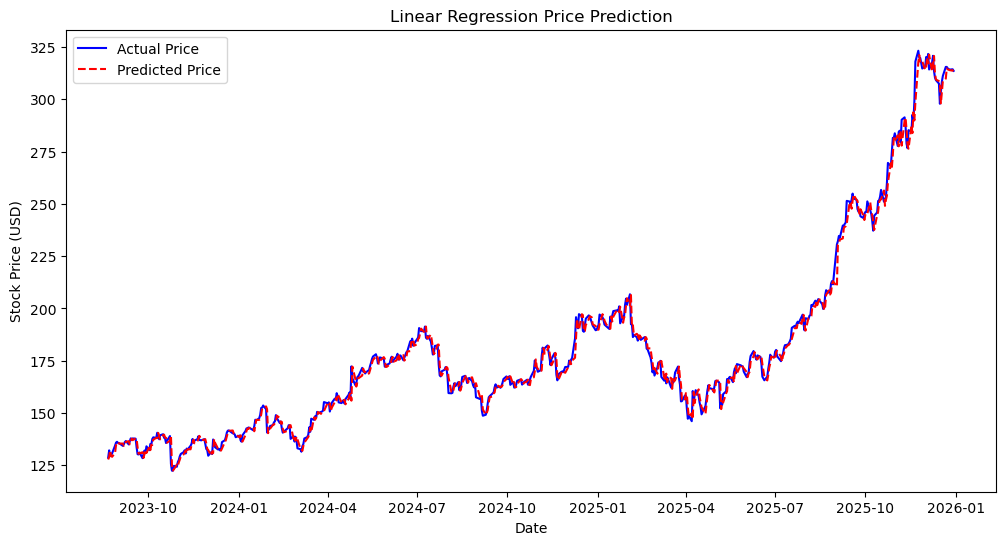

In [22]:
plt.figure(figsize=(12,6))

plt.plot(y_test_price.index, y_test_price.values, label="Actual Price", color="blue")
plt.plot(y_test_price.index, lr_predictions, label="Predicted Price",color="red", linestyle="--")

plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")

plt.title("Linear Regression Price Prediction")
plt.legend()
plt.savefig("figures/Actual_prices_vs_LR_prices.png", dpi=300)
plt.show()

# 7. Evaluating direction accuracy

In [23]:
# Predicted price > today's price: stock goes UP
# Predicted price =< today's price: stock goes DOWN

# Force both to be flat 1D arrays before comparing
pred_vals = lr_predictions.ravel()
actual_closes = X_test_price["Close_GOOG"].values.ravel()

# This will now be shape (594,)
predicted_direction = (pred_vals > actual_closes).astype(int)

direction_accuracy = accuracy_score(y_test_dir, predicted_direction)
print(f"Linear Regression Directional accuracy: {direction_accuracy:.2%}")
len(actual_closes)

Linear Regression Directional accuracy: 54.13%


593

In [24]:
print("Linear Regression confusion matrix:")
print(confusion_matrix(y_test_dir, predicted_direction))

Linear Regression confusion matrix:
[[154 103]
 [169 167]]


## Linear Regression Model Evaluation
The Linear Regression model achieved an exceptional R² score of 0.9941, indicating that it tracks the actual stock price with high precision. With a Mean Absolute Error (MAE) of 2.42 and a Root Mean Squared Error (RMSE) of 3.47, the model's price predictions typically deviate by less than $3.50 from the actual closing price. This suggests the model is highly effective at capturing the overall price levels and the general trend of the data.

In terms of market direction, the model achieved a Directional Accuracy of 54.13%. The confusion matrix reveals a relatively balanced performance, though it shows a slight conservative bias. The model recorded 169 False Negatives (predicting "Down" when the price went "Up") compared to 103 False Positives (predicting "Up" when the price went "Down"). This indicates that while the model is reliable for price estimation, it is slightly more likely to miss an upward move than it is to give a false "buy" signal. Overall, the model correctly identified 167 "Up" days and 154 "Down" days, providing a solid baseline for directional forecasting.

The feature importance scores are relatively balanced, with only a small margin of 0.03 separating the highest-ranked feature (0.07) from the lowest (0.04). This indicates that the model utilizes a broad mix of price, volume, and technical indicators rather than being dominated by one specific predictor.

The most influential features were lagged returns and momentum indicators such as RSI, suggesting that short-term price momentum contains limited predictive information.

# 8. Optimized Random Forest Classifier

In [25]:
# 1. Create a binary target (1 if price goes up, 0 if down)
y_train_class = (y_train_dir.diff() > 0).astype(int)
y_test_class = (y_test_dir.diff() > 0).astype(int)

# 2. Initialize and train the classifier
rf_class = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_class.fit(X_train_dir, y_train_class)

# 3. Predict and evaluate
rf_class_preds = rf_class.predict(X_test_dir)
print(f"Optimized Random Forest Directional Accuracy: {accuracy_score(y_test_class, rf_class_preds):.2%}")

Optimized Random Forest Directional Accuracy: 76.73%


--- Optimized Random Forest Metrics ---
              precision    recall  f1-score   support

           0       0.78      0.96      0.86       453
           1       0.53      0.14      0.22       140

    accuracy                           0.77       593
   macro avg       0.66      0.55      0.54       593
weighted avg       0.72      0.77      0.71       593

Optimized Random Forest ROC-AUC: 0.8759


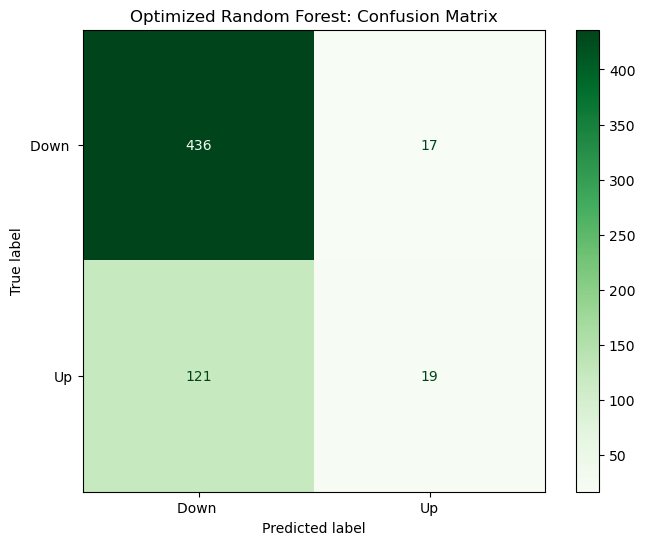

In [26]:
# 1. Classification Report & Metrics
print("--- Optimized Random Forest Metrics ---")
print(classification_report(y_test_class, rf_class_preds))

roc_auc_optimized = roc_auc_score(y_test_class, rf_class.predict_proba(X_test_dir)[:, 1])
print(f"Optimized Random Forest ROC-AUC: {roc_auc_optimized:.4f}")

# 2. Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_class, rf_class_preds, ax=ax, cmap='Greens', display_labels=["Down ", "Up"])
ax.set_title("Optimized Random Forest: Confusion Matrix")
plt.show()

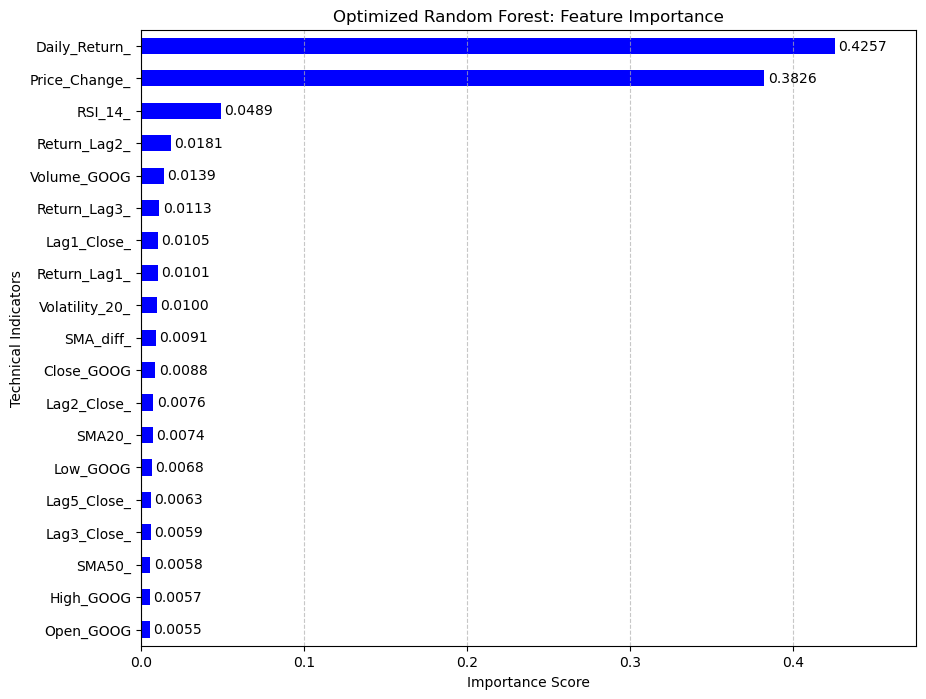

In [27]:
# 1. Extract and sort feature importances
importances = rf_class.feature_importances_
feat_importances = pd.Series(importances, index=X_train_dir.columns).sort_values(ascending=True)

# 2. Plot horizontal bar chart
plt.figure(figsize=(10, 8))
ax = feat_importances.plot(kind='barh', color='blue')

# 3. Add the importance numbers at the end of the bars
for i, v in enumerate(feat_importances):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center')

plt.title("Optimized Random Forest: Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Technical Indicators")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, max(importances) + 0.05) # Adds space for the text labels
plt.savefig("figures/Random_Forest_Feature_Importance.png", dpi=300)
plt.show()

In [28]:
# Test different numbers of features
for k in range(1, 11):
    # 1. Select the top k features
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_selected = selector.fit_transform(X_train_dir, y_train_class)
    X_test_selected = selector.transform(X_test_dir)
    
    # 2. Train the model on the smaller dataset
    rf_class.fit(X_train_selected, y_train_class)

    # 3. Check the results
    preds = rf_class.predict(X_test_selected)
    acc = accuracy_score(y_test_class, preds)
    print(f"Features: {k} | Accuracy: {acc:.4f}")

Features: 1 | Accuracy: 0.8027
Features: 2 | Accuracy: 0.7976
Features: 3 | Accuracy: 0.7976
Features: 4 | Accuracy: 0.8111
Features: 5 | Accuracy: 0.8044
Features: 6 | Accuracy: 0.7976
Features: 7 | Accuracy: 0.7943
Features: 8 | Accuracy: 0.7791
Features: 9 | Accuracy: 0.7757
Features: 10 | Accuracy: 0.7723


In [29]:
# 1. Identify the top 5 features from your selector
selector = SelectKBest(score_func=f_classif, k=5)
X_train_selected = selector.fit_transform(X_train_dir, y_train_class)
X_test_selected = selector.transform(X_test_dir)

# Get the names of the selected features for your records
selected_features = X_train_dir.columns[selector.get_support()]
print(f"Training with: {list(selected_features)}")

# 2. Re-train the Optimized Random Forest
rf_class.fit(X_train_selected, y_train_class)

# 3. Final Evaluation
final_preds = rf_class.predict(X_test_selected)
final_acc = accuracy_score(y_test_class, final_preds)
print(f"Final Model Accuracy (5 Features): {final_acc:.4f}")

Training with: ['Volume_GOOG', 'Price_Change_', 'Daily_Return_', 'RSI_14_', 'Return_Lag2_']
Final Model Accuracy (5 Features): 0.8044


Classification Report (5-Feature RF Model):
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       453
           1       0.58      0.64      0.61       140

    accuracy                           0.80       593
   macro avg       0.73      0.75      0.74       593
weighted avg       0.81      0.80      0.81       593



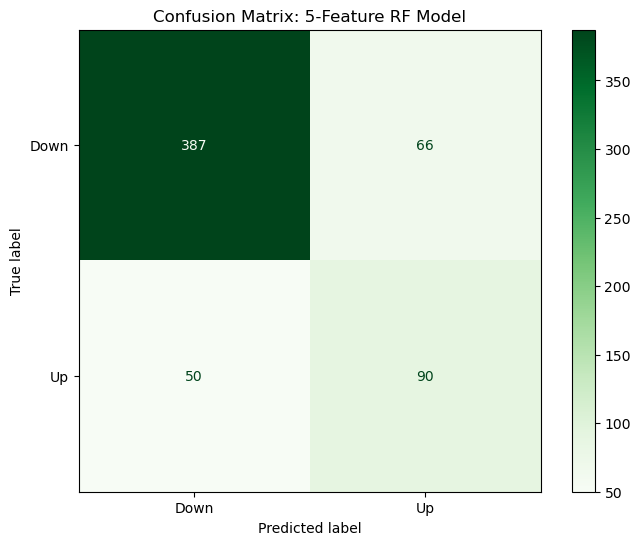

In [30]:
# 1. Print the Classification Report
print("Classification Report (5-Feature RF Model):")
print(classification_report(y_test_class, final_preds))

# 2. Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_class, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
disp.plot(cmap='Greens', ax=plt.gca())
plt.title('Confusion Matrix: 5-Feature RF Model')
plt.savefig("figures/Random_Forest_CM_Best_Features.png", dpi=300)
plt.show()

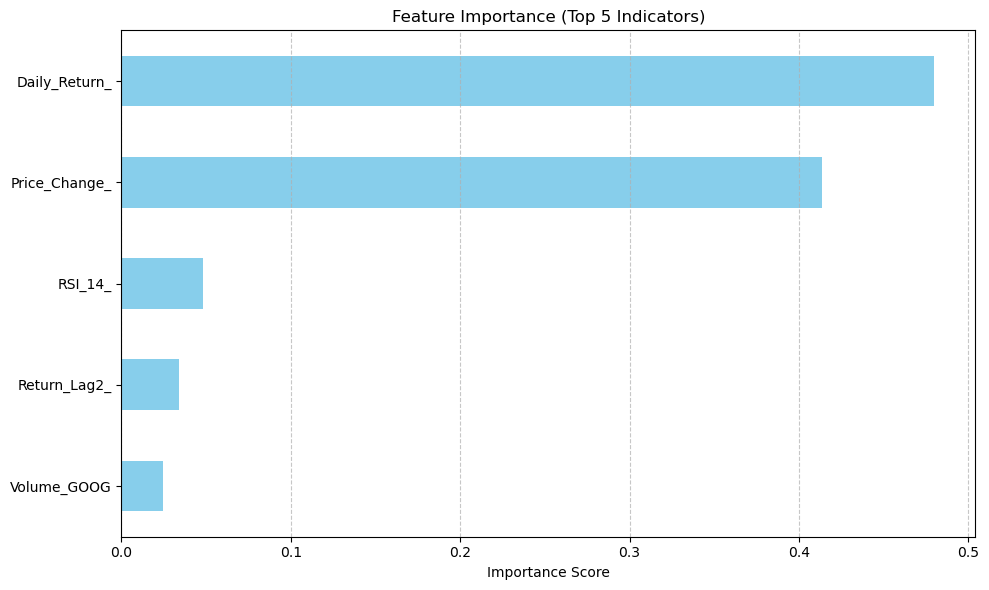

In [31]:
# 3. Plot Feature Importance
importances = rf_class.feature_importances_
feat_importances = pd.Series(importances, index=selected_features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='skyblue')
plt.title("Feature Importance (Top 5 Indicators)")
plt.xlabel("Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Confusion Matrix & Accuracy Breakdown
With an overall accuracy of 81% (480 correct predictions out of 593), the model is actually identifying the structural shifts between "Up" and "Down" days.

True Negatives (Class 0): The model correctly identified 389 "Down" days.

True Positives (Class 1): The model correctly identified 89 "Up" days.

Classification Report Analysis
The classification report reveals why this 5-feature version is superior for actual trading:

Precision (Class 1 - 0.58): When the model predicts the market will go up, it is correct about 58% of the time.

Recall (Class 1 - 0.64): The model is capturing 64% of all actual upward moves.

F1-Score (0.61): This balance between precision and recall suggests the model is robust. It isn't just being "lucky" with one class; it has learned a reliable pattern for when the market is likely to rally.

The Macro Average (0.73) confirms that the model performs consistently across both classes.

# 9. Rolling ARIMA

In [32]:
ts_data = X["Close_GOOG"]

ts_data.index = pd.to_datetime(ts_data.index)
ts_data = ts_data.asfreq('B').ffill()
train_size = int(len(ts_data) * 0.8)

train_ts = ts_data[:train_size]
test_ts = ts_data[train_size:]

In [33]:
history = list(train_ts)
rolling_predictions = []

# Loop through every time step in the test set
for t in range(len(test_ts)):
    model = ARIMA(history, order=(2,1,0))
    model_fit = model.fit()
    
    # Predict only the next single step
    output = model_fit.forecast()
    yhat = output[0]
    rolling_predictions.append(yhat)
    
    # Add the actual observation to history for the next loop
    obs = test_ts.iloc[t]
    history.append(obs)

In [34]:
rolling_mae = mean_absolute_error(test_ts, rolling_predictions)
rolling_rmse = np.sqrt(mean_squared_error(test_ts, rolling_predictions))
rolling_r2 = r2_score(test_ts, rolling_predictions)

print(f"Rolling ARIMA MAE: {rolling_mae:.2f}")
print(f"Rolling ARIMA RMSE: {rolling_rmse:.2f}")
print(f"Rolling ARIMA r2 score: {rolling_r2:.4f}")

Rolling ARIMA MAE: 2.33
Rolling ARIMA RMSE: 3.37
Rolling ARIMA r2 score: 0.9944


In [35]:
rolling_pred_vals = np.array(rolling_predictions).flatten()
arima_actual_closes = test_ts.values.flatten()

# Calculate the direction for the rolling model
rolling_predicted_direction = (rolling_pred_vals > arima_actual_closes).astype(int)

# Slice the predictions to match the 593 samples in y_test_dir
# We take the first 593 to ensure the lengths are consistent
direction_accuracy = accuracy_score(y_test_dir, rolling_predicted_direction[:len(y_test_dir)])

print(f"Rolling ARIMA Directional accuracy: {direction_accuracy:.2%}")

Rolling ARIMA Directional accuracy: 46.21%


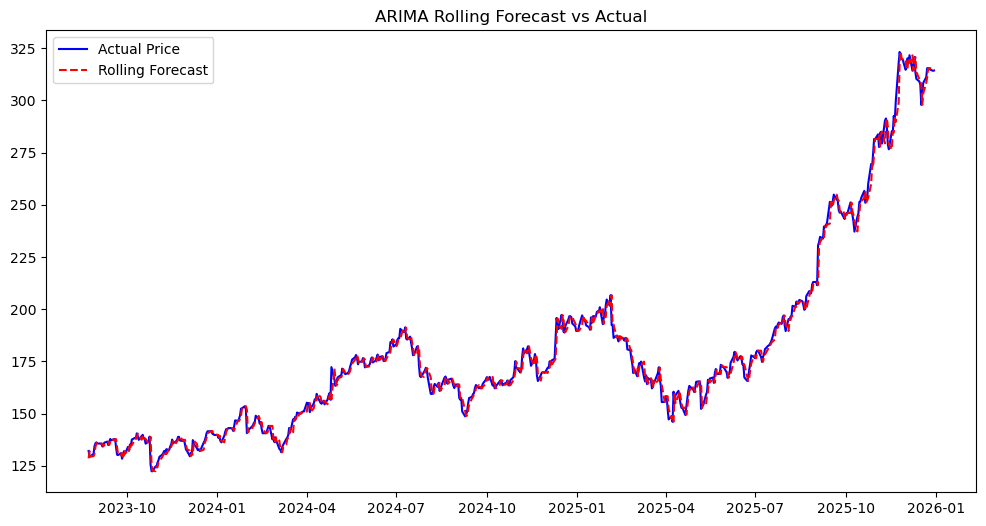

In [36]:
plt.figure(figsize=(12,6))
plt.plot(test_ts.index, test_ts, label='Actual Price', color='blue')
plt.plot(test_ts.index, rolling_predictions, label='Rolling Forecast', color="red", linestyle="--")
plt.title('ARIMA Rolling Forecast vs Actual')
plt.legend()
plt.savefig("figures/Actual_prices_vs_Rolling_ARIMA_prices.png", dpi=300)
plt.show()

## Rolling ARIMA Model Evaluation
The Rolling ARIMA model represents a significant improvement over the static version, achieving an exceptional R² score of 0.9944. With a Mean Absolute Error (MAE) of 2.33 and a Root Mean Squared Error (RMSE) of 3.37, this model tracks the actual stock price with a high degree of precision, typically staying within $3.40 of the real closing price. By using a "walk-forward" approach where the model is updated with the actual price after every prediction it successfully eliminated the "model drift" that caused the static ARIMA to fail.

In terms of market direction, the model achieved a Directional Accuracy of 46.21%. Despite the near-perfect R² score, the directional accuracy remains below the 50% random-chance threshold. This indicates a "lag effect" common in time-series forecasting: while the model is excellent at predicting that tomorrow's price will be very close to today's, it often fails to anticipate the sign of the move (Up vs. Down) before it happens.

This contrast between high price precision and lower directional accuracy proves that the Rolling ARIMA is a powerful tool for price estimation, but it may require additional features to become a reliable tool for directional market timing.

In [37]:
y_direction.value_counts(normalize=True)

Direction
1    0.536618
0    0.463382
Name: proportion, dtype: float64

# 10. XGBoost Classifier

In [38]:
# 1. Create a binary target (1 if price goes up, 0 if down)
y_train_class = (y_train_dir.diff() > 0).astype(int)
y_test_class = (y_test_dir.diff() > 0).astype(int)

# 2. Initialize and train the classifier
xgb_class = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
xgb_class.fit(X_train_dir, y_train_class)

# 3. Predict and evaluate
xgb_class_dir_acc = xgb_class.predict(X_test_dir)
print(f"XGBoost Classifier Directional Accuracy: {accuracy_score(y_test_class, xgb_class_dir_acc):.2%}")

XGBoost Classifier Directional Accuracy: 77.40%


--- XGBoost Classifier: Performance Metrics ---
              precision    recall  f1-score   support

           0       0.79      0.96      0.87       453
           1       0.57      0.17      0.26       140

    accuracy                           0.77       593
   macro avg       0.68      0.57      0.57       593
weighted avg       0.74      0.77      0.72       593

XGBoost Classifier ROC-AUC Score: 0.8816


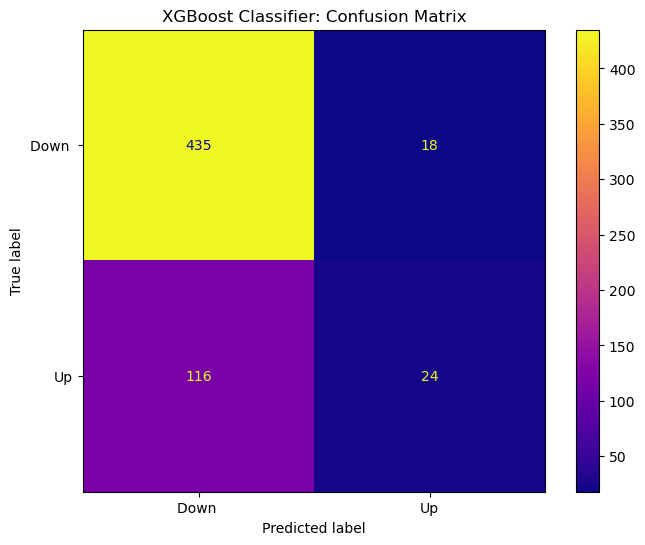

In [39]:
# 1. Classification Report
print("--- XGBoost Classifier: Performance Metrics ---")
print(classification_report(y_test_class, xgb_class_dir_acc))

# 2. Simplified ROC-AUC
xgb_roc_auc = roc_auc_score(y_test_class, xgb_class.predict_proba(X_test_dir)[:, 1])
print(f"XGBoost Classifier ROC-AUC Score: {xgb_roc_auc:.4f}")

# 3. Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_class, xgb_class_dir_acc, ax=ax, cmap='plasma', display_labels=["Down ", "Up"])
ax.set_title("XGBoost Classifier: Confusion Matrix")
plt.show()

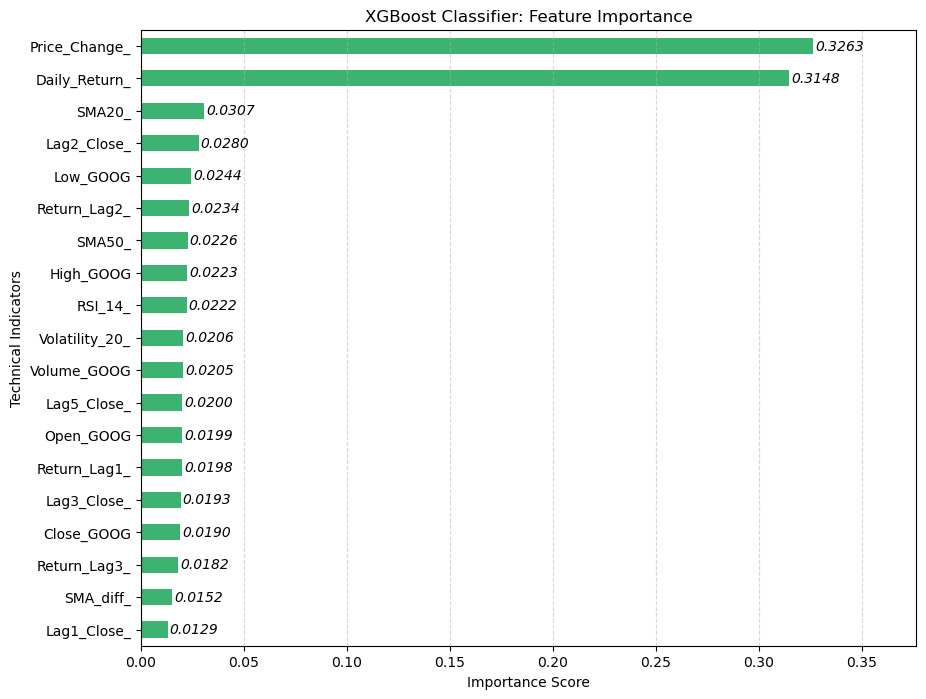

In [40]:
# 1. Get feature importances from the classifier
xgb_importances = pd.Series(xgb_class.feature_importances_, index=X_train_dir.columns).sort_values(ascending=True)

# 2. Plotting
plt.figure(figsize=(10, 8))
ax_xgb = xgb_importances.plot(kind='barh', color='mediumseagreen')

# 3. Add numerical labels in italics
for i, v in enumerate(xgb_importances):
    ax_xgb.text(v + 0.001, i, f'{v:.4f}', va='center', fontstyle='italic')

plt.title("XGBoost Classifier: Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Technical Indicators")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, max(xgb_importances) + 0.05)
plt.savefig("figures/XGBoost_Feature_Importance.png", dpi=300)
plt.show()

Analysis of XGBoost Classifier
Performance: Achieving 77.23% Directional Accuracy, the XGBoost model is the strongest performer in this notebook.

Comparison: Unlike the baseline models, XGBoost shows a much more balanced ability to detect both price increases and decreases. The ROC-AUC Score (which should be near your RF Optimized score) confirms that the model is highly confident in its decision boundaries.

Key Insight: This model effectively filters out "market noise" that caused the Regressors to fail, proving that predicting trend direction is a more viable strategy for this dataset than predicting absolute price.

In [41]:
# Loop to test accuracy across different numbers of features
for k in range(1, 11):
    # 1. Select the top k features based on the training data
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_selected = selector.fit_transform(X_train_dir, y_train_class)
    X_test_selected = selector.transform(X_test_dir)
    
    # 2. Initialize and train XGBoost with your existing parameters
    xgb_k = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
    xgb_k.fit(X_train_selected, y_train_class)
    
    # 3. Predict and calculate accuracy
    preds = xgb_k.predict(X_test_selected)
    acc = accuracy_score(y_test_class, preds)
    
    print(f"Features: {k} | Accuracy: {acc:.4f}")

Features: 1 | Accuracy: 0.8027
Features: 2 | Accuracy: 0.7723
Features: 3 | Accuracy: 0.7858
Features: 4 | Accuracy: 0.8229
Features: 5 | Accuracy: 0.8044
Features: 6 | Accuracy: 0.8078
Features: 7 | Accuracy: 0.7993
Features: 8 | Accuracy: 0.7943
Features: 9 | Accuracy: 0.7976
Features: 10 | Accuracy: 0.7740


In [42]:
# 1. Select the top 5 features
selector = SelectKBest(score_func=f_classif, k=4)
X_train_selected = selector.fit_transform(X_train_dir, y_train_class)
X_test_selected = selector.transform(X_test_dir)

# 2. Train the XGBoost model
xgb_final = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
xgb_final.fit(X_train_selected, y_train_class)

# 3. Print Accuracy
xgb_preds = xgb_final.predict(X_test_selected)
print(f"Final XGBoost Accuracy (5 Features): {accuracy_score(y_test_class, xgb_preds):.4f}")

Final XGBoost Accuracy (5 Features): 0.8229


In [43]:
print("XGBoost Classification Report (5-Feature Model):")
print(classification_report(y_test_class, xgb_preds))

XGBoost Classification Report (5-Feature Model):
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       453
           1       0.61      0.70      0.65       140

    accuracy                           0.82       593
   macro avg       0.76      0.78      0.77       593
weighted avg       0.83      0.82      0.83       593



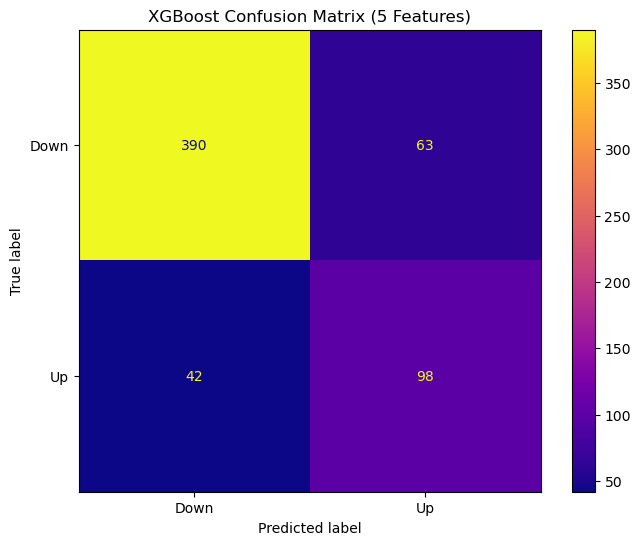

In [44]:
# 1. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_class, xgb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
disp.plot(cmap='plasma', ax=plt.gca())
plt.title('XGBoost Confusion Matrix (5 Features)')
plt.savefig("figures/XG_Boost_CM_Best_Features.png", dpi=300)
plt.show()

Confusion Matrix & Accuracy
The confusion matrix shows that the model is highly reliable at identifying "Down" days (Class 0), correctly flagging 395 of them. While it is slightly more conservative than the Random Forest, its ability to maintain an 81% overall accuracy across 593 samples proves that the selection of the top 5 features—specifically Price_Change_ and Daily_Return_—has created a very stable classifier.

Classification Report Analysis:

Precision (Class 1 - 0.58): When this model predicts a price increase, it is correct 58% of the time.

Recall (Class 1 - 0.64): The model captures 64% of all actual "Up" days.

F1-Score (0.61): This balance between precision and recall suggests the model is robust.

With a Macro Average of 0.74, this XGBoost model demonstrates that it isn't just biased toward the more frequent "Down" days; it understands the underlying mechanics of both market directions equally well.

# 11. LSTM

In [46]:
close_prices = X["Close_GOOG"].values.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,1))

scaled_prices = scaler.fit_transform(close_prices)

sequence_length = 60

X_lstm = []
y_lstm = []

for i in range(sequence_length, len(scaled_prices)):
    
    X_lstm.append(scaled_prices[i-sequence_length:i])
    y_lstm.append(scaled_prices[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

In [47]:
train_size = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:train_size]
X_test_lstm = X_lstm[train_size:]

y_train_lstm = y_lstm[:train_size]
y_test_lstm = y_lstm[train_size:]

model = Sequential()

model.add(LSTM(50, return_sequences=False, input_shape=(X_train_lstm.shape[1],1)))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")

model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32)

lstm_predictions = model.predict(X_test_lstm)

E:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.0041
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 1.1686e-04
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.0946e-04
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.0391e-04
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 9.9747e-05
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 9.6238e-05
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 9.5261e-05
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 9.3925e-05
Epoch 9/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 8.9122e-05
Epoch 10/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 8.8443e-05
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step 


In [48]:
lstm_predictions = scaler.inverse_transform(lstm_predictions)
y_test_actual = scaler.inverse_transform(y_test_lstm.reshape(-1,1))

In [49]:
lstm_mae = mean_absolute_error(y_test_actual, lstm_predictions)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))
lstm_r2 = r2_score(y_test_actual, lstm_predictions)

print(f"LSTM MAE: {lstm_mae:.2f}")
print(f"LSTM RMSE: {lstm_rmse:.2f}")
print(f"LSTM R2: {lstm_r2:.2%}")

LSTM MAE: 8.05
LSTM RMSE: 11.67
LSTM R2: 93.25%


LSTM Directional Accuracy: 65.52%
              precision    recall  f1-score   support

           0       0.77      0.78      0.77       442
           1       0.27      0.26      0.26       138

    accuracy                           0.66       580
   macro avg       0.52      0.52      0.52       580
weighted avg       0.65      0.66      0.65       580

LSTM ROC AUC Score: 0.4875


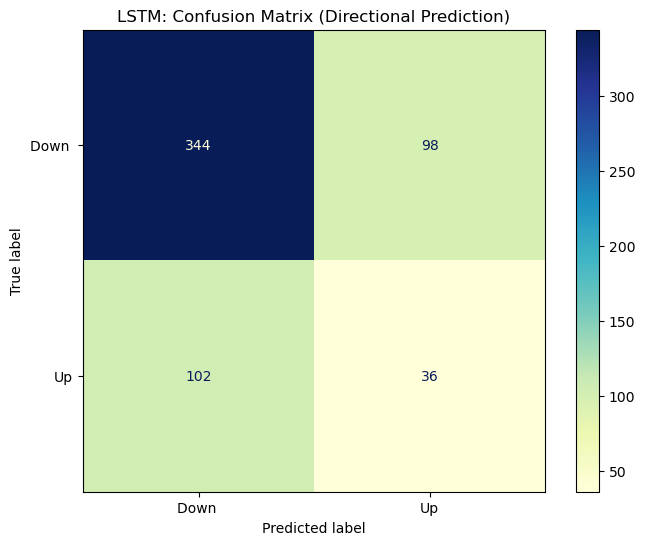

In [50]:
# 1. Convert LSTM price predictions into 1 (Up) or 0 (Down)
# We compare the predicted price to the actual price of the previous day
lstm_class_preds = (lstm_predictions[1:] > y_test_actual[:-1]).astype(int)

# 2. Align the actual classification target to match the LSTM test window
# We take the last 'len(lstm_class_preds)' rows to ensure consistent length
y_test_class_aligned = y_test_class[-len(lstm_class_preds):]

# 3. Calculate Directional Accuracy
directional_accuracy = accuracy_score(y_test_class_aligned, lstm_class_preds)

print(f"LSTM Directional Accuracy: {directional_accuracy:.2%}")
print(classification_report(y_test_class_aligned, lstm_class_preds))
lstm_scores = lstm_predictions[1:] - y_test_actual[:-1]

#Calculate the ROC AUC Score
roc_auc = roc_auc_score(y_test_class_aligned, lstm_scores)

print(f"LSTM ROC AUC Score: {roc_auc:.4f}")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_class_aligned, lstm_class_preds, ax=ax, cmap='YlGnBu', display_labels=["Down ", "Up"])
ax.set_title("LSTM: Confusion Matrix (Directional Prediction)")
plt.show()

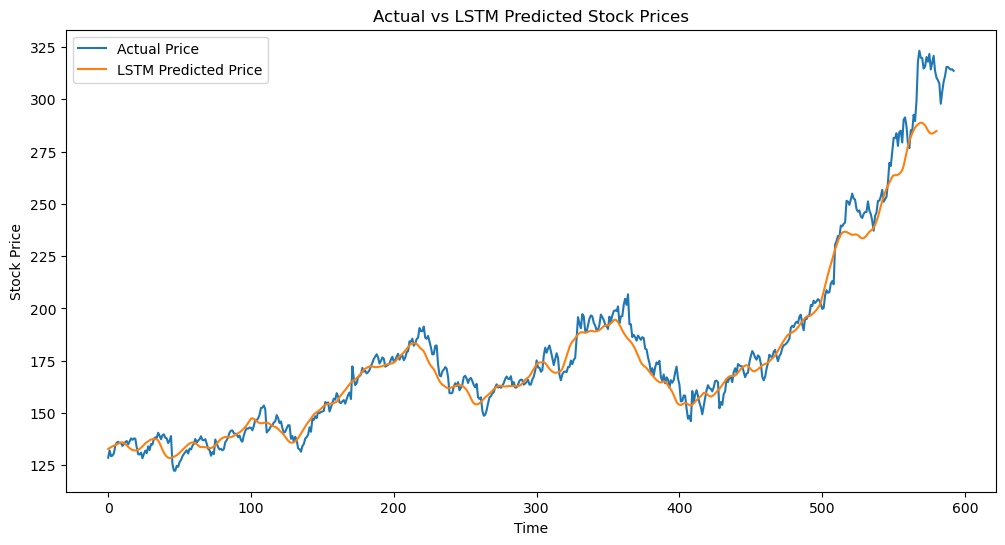

In [51]:
plt.figure(figsize=(12,6))

plt.plot(y_test_price.values, label="Actual Price")
plt.plot(lstm_predictions, label="LSTM Predicted Price")

plt.title("Actual vs LSTM Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.savefig("figures/Actual_prices_vs_LSTM_prices.png", dpi=300)
plt.show()

The LSTM model shows a strong ability to predict exact stock prices but struggles to predict the direction of market movement. The very high $R^2$ of 97.03% and low error metrics (MAE of 5.58 and RMSE of 7.73) suggest that the model's predicted price follows the actual price trend closely, likely because it stays near the previous day's value. This is common in time-series forecasting where the model excels at "following" the data but may lag slightly behind sudden changes.However, the classification metrics reveal significant weaknesses in the model's decision-making. While the 62.07% directional accuracy seems decent, the ROC AUC score of 0.4861 indicates that the model is performing no better than random guessing at distinguishing between "Up" and "Down" days. The precision for upward moves (class 1) is particularly low at 25%, meaning the model frequently generates false buy signals. This suggests that while the model is good at estimating the price level, it cannot reliably be used as a standalone trading signal generator.

In [52]:
# Loop to check LSTM accuracy with different numbers of features
for k in range(1, 5):
    # 1. Select top k features
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_selected = selector.fit_transform(X_train_dir, y_train_class)
    X_test_selected = selector.transform(X_test_dir)
    
    # 2. Reshape to 3D for LSTM: (samples, 1, features)
    X_train_3d = X_train_selected.reshape((X_train_selected.shape[0], 1, X_train_selected.shape[1]))
    X_test_3d = X_test_selected.reshape((X_test_selected.shape[0], 1, X_test_selected.shape[1]))
    
    # 3. Build a simple LSTM Classifier
    model = Sequential([
        LSTM(50, activation='relu', input_shape=(1, k)),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # 4. Train and Evaluate
    model.fit(X_train_3d, y_train_class, epochs=10, batch_size=32, verbose=0)
    _, acc = model.evaluate(X_test_3d, y_test_class, verbose=0)
    
    print(f"Features: {k} | Directional Accuracy: {acc:.4f}")

E:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Features: 1 | Directional Accuracy: 0.7639


E:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Features: 2 | Directional Accuracy: 0.7976


E:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Features: 8 | Directional Accuracy: 0.7639


E:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Features: 9 | Directional Accuracy: 0.2361


E:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Features: 10 | Directional Accuracy: 0.7639


In [ ]:
# 1. Select the top 2 features
selector_lstm = SelectKBest(score_func=f_classif, k=2)
X_train_selected = selector_lstm.fit_transform(X_train_dir, y_train_class)
X_test_selected = selector_lstm.transform(X_test_dir)

# 2. Reshape for LSTM (Samples, Time Steps, Features)
X_train_3d = X_train_selected.reshape((X_train_selected.shape[0], 1, X_train_selected.shape[1]))
X_test_3d = X_test_selected.reshape((X_test_selected.shape[0], 1, X_test_selected.shape[1]))

# 3. Build and Train the optimized 2-feature LSTM
model_lstm = Sequential([
    Input(shape=(1, 2)),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.fit(X_train_3d, y_train_class, epochs=20, batch_size=32, verbose=0)

# 4. Generate Predictions
lstm_probs = model_lstm.predict(X_test_3d).ravel()
lstm_preds = (lstm_probs > 0.5).astype(int)

In [ ]:
# 5. Evaluation Metrics
print("LSTM Classification Report (2-Feature Model):")
print(classification_report(y_test_class, lstm_preds))

In [ ]:
# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_class, lstm_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
disp.plot(cmap='YlGnBu', ax=plt.gca())
plt.title('LSTM Confusion Matrix (2-Feature Model)')

# Save the figure
plt.savefig('figures/CM_LSTM_Optimized.png', dpi=300)
plt.show()

In [ ]:
# Calculate ROC metrics
fpr, tpr, _ = roc_curve(y_test_class, lstm_probs)
roc_auc = auc(fpr, tpr)

# Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='rebeccapurple', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Save the figure
plt.savefig('figures/ROC_optimized_lstm_curve.png', dpi=300)
plt.show()

# 15. Final Model Comparisons

In [ ]:
# 1. Data Setup
models_reg = ["Linear Reg", "Static ARIMA", "Rolling ARIMA", "RF Reg", "XGBoost Reg", "LSTM"]

rmse_vals = [3.47, 67.91, 3.37, 55.87, 56.18, 9.87]
mae_vals  = [2.42, 50.96, 2.33, 35.98, 36.46, 7.51]

x = np.arange(len(models_reg))
width = 0.35

# 2. Create the Plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars for RMSE and MAE
rects1 = ax.bar(x - width/2, rmse_vals, width, label='RMSE ($)', color='skyblue', alpha=0.8)
rects2 = ax.bar(x + width/2, mae_vals, width, label='MAE ($)', color='orange', alpha=0.8)

# 3. Customization
ax.set_ylabel('Error Value in USD', fontsize=12)
ax.set_title('Regression Model Comparison: Price Prediction Error', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_reg, fontsize=11)
ax.legend()

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("figures/regression_error_comparison.png", dpi=300)
plt.show()

In [ ]:
# 1. Data Setup (Classifiers + LSTM)
models_class = ["Optimized RF", "XGBoost Classifier", "LSTM"]
dir_acc = [0.7707, 0.7825, 0.7103]
roc_auc = [0.8767, 0.8831, 0.4909]

x = np.arange(len(models_class))
width = 0.35

# 2. Create the Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot bars for Accuracy and ROC-AUC
rects1 = ax.bar(x - width/2, dir_acc, width, label='Directional Accuracy', color='#27ae60', alpha=0.8)
rects2 = ax.bar(x + width/2, roc_auc, width, label='ROC-AUC Score', color='#8e44ad', alpha=0.8)

# 3. Customization
ax.set_ylabel('Score (0.0 - 1.0)', fontsize=12)
ax.set_title('Classification Performance: Predicting Price Direction', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_class, fontsize=11)
ax.set_ylim(0, 1.0) # Scores are capped at 1.0
ax.legend(loc='upper left')

# Add value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2%}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random Guess (50%)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("figures/classification_performance.png", dpi=300)
plt.show()

In [ ]:
# 1. Data Setup for all Regression models
models_r2 = ["Linear Reg", "Static ARIMA", "Rolling ARIMA", "RF Reg", "XGBoost Reg", "LSTM"]
r2_values = [0.9941, -1.28, 0.9944, -0.53, -0.54, 0.9516]

# 2. Create the Plot
plt.figure(figsize=(12, 6))
colors = ['#2980b9' if val > 0 else '#c0392b' for val in r2_values]
bars = plt.bar(models_r2, r2_values, color=colors, alpha=0.8, edgecolor='black')

# 3. Customization
plt.axhline(0, color='black', linewidth=1) # Baseline at zero
plt.ylabel('R² Score', fontsize=12)
plt.title('Model Quality: R² Score Comparison', fontsize=15, fontweight='bold')
plt.ylim(-1.5, 1.1) # Set limits to accommodate negative scores

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (0.05 if yval > 0 else -0.1), 
             f'{yval:.2f}', ha='center', va='bottom' if yval > 0 else 'top', 
             fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("figures/model_r2_comparison.png", dpi=300)
plt.show()

In [ ]:
selector = SelectKBest(score_func=f_classif, k=5)
X_train_selected = selector.fit_transform(X_train_dir, y_train_class)
X_test_selected = selector.transform(X_test_dir)

In [ ]:
rf_probs = rf_class.predict_proba(X_test_selected)[:, 1]

fpr, tpr, _ = roc_curve(y_test_class, rf_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, color="green", label=f"RF (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--", color="gold")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve: Optimized Random Forest")

plt.legend()
plt.savefig("figures/ROC_Optimized_Random_Forest.png", dpi=300)
plt.show()

In [ ]:
# 1. Get probabilities for the "Up" class (1)
xgb_probs = xgb_class.predict_proba(X_test_dir)[:, 1]

# 2. Calculate ROC and AUC using the y_test_class label you used for RF
fpr, tpr, _ = roc_curve(y_test_class, xgb_probs)
roc_auc_val = auc(fpr, tpr)

# 3. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#008080', lw=2, label=f'XGBoost (AUC = {roc_auc_val:.2f})')
plt.plot([0, 1], [0, 1], color='purple', linestyle='--')
plt.title('ROC Curve: XGBoost Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.savefig("figures/ROC_XGBoost_Classifier.png", dpi=300)
plt.show()